In [5]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage05_path = os.path.join(repo_root, "scripts", "05_permulation_loss_dup")
for path in (src_path, stage05_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-05 path: {stage05_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-05 path: /Users/calvin/orb-selection/scripts/05_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loss

81 species total, 27 foreground, 54 background                                                  
Mean: -1.07, Stddev: 2.03, Count: 5316                                                          


/Users/calvin/orb-selection/scripts/05_permulation_loss_dup/odds_ratio_test.py:279: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Optimized triple Gaussian parameters:                                                           
  weight_1: 0.248                                                                               
  mean_1: -3.261                                                                                
  stddev_1: 0.773                                                                               
  weight_2: 0.626                                                                               
  mean_2: -0.709                                                                                
  stddev_2: 1.232                                                                               
  mean_3: 1.322                                                                                 
  stddev_3: 2.730                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 2192                                            
Permutation counter for MEAN 1 (triple Gaussian): 160                                           
Permutation counter for MEAN 2 (triple Gaussian): 4445                                          
Permutation counter for MEAN 3 (triple Gaussian): 3719                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 40, <= 78 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-3.69941309  3.15291265]                             
                                                                                                
*********************** RESULTS ***********************                                         
                                                                                                
Permutation test with 10000 re

Processing HOGs:   0%|          | 0/629 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr08/Run2_Loss_LT_40-78_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

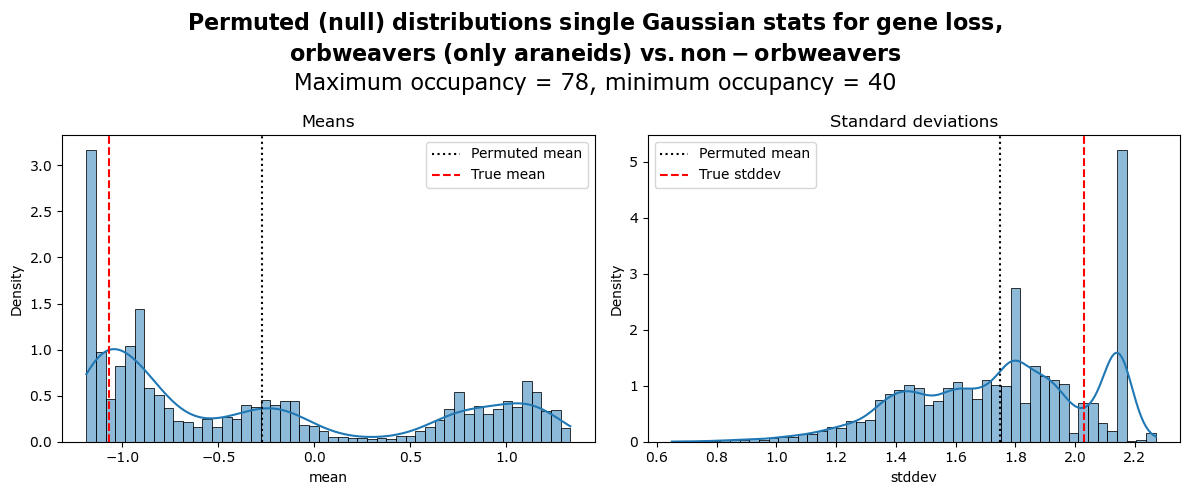

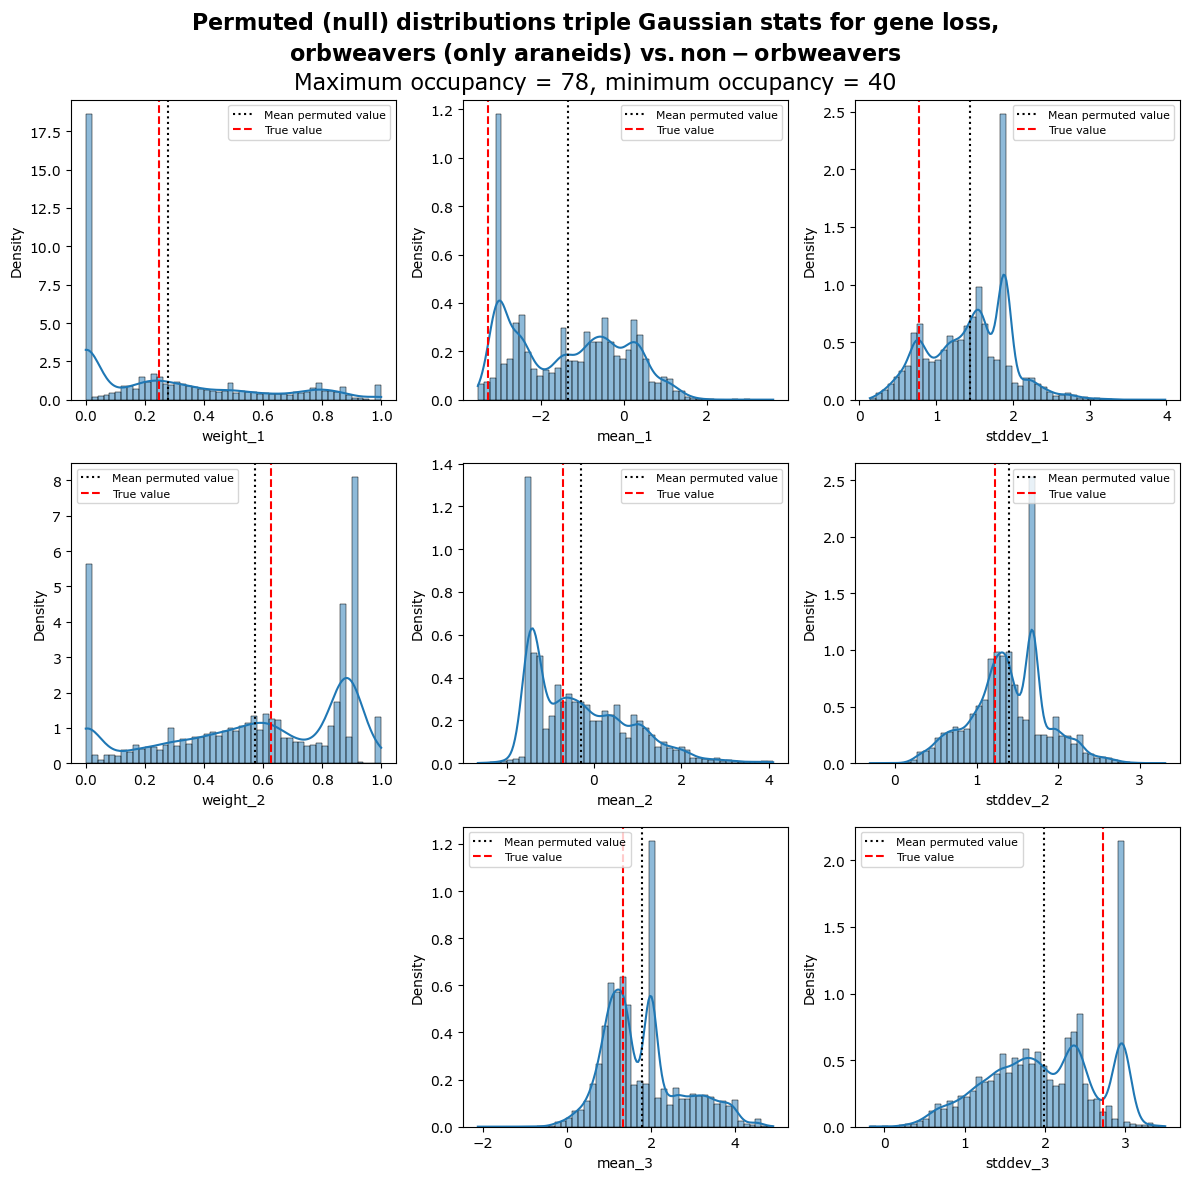

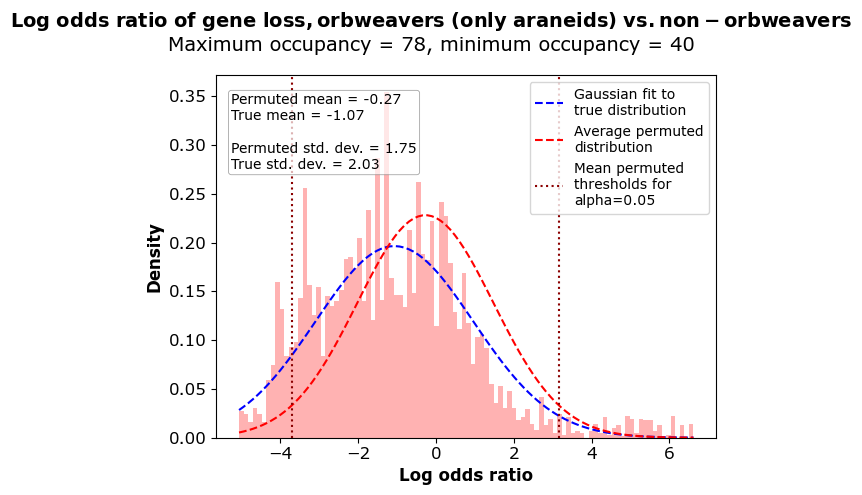

In [6]:
%autoreload 2
loss_lt_40_78 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=40,
    max_occ=78,
    alternative="less",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (only araneids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/araneids-orbweavers.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_only_araneids.csv",
    save_two_tailed_hits=True,
)

## Duplication

81 species total, 27 foreground, 54 background                                                  
Mean: -0.06, Stddev: 1.19, Count: 8179                                                          


/Users/calvin/orb-selection/scripts/05_permulation_loss_dup/odds_ratio_test.py:279: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Optimized triple Gaussian parameters:                                                           
  weight_1: 0.180                                                                               
  mean_1: -1.036                                                                                
  stddev_1: 0.862                                                                               
  weight_2: 0.527                                                                               
  mean_2: -0.011                                                                                
  stddev_2: 0.785                                                                               
  mean_3: 0.467                                                                                 
  stddev_3: 1.558                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 7692                                            
Permutation counter for MEAN 1 (triple Gaussian): 9344                                          
Permutation counter for MEAN 2 (triple Gaussian): 9454                                          
Permutation counter for MEAN 3 (triple Gaussian): 9881                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 40, <= 81 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-2.18232747  2.1889348 ]                             
                                                                                                
*********************** RESULTS ***********************                                         
                                                                                                
Permutation test with 10000 re

Processing HOGs:   0%|          | 0/604 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr08/Run4_Dup_RT_40-max_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

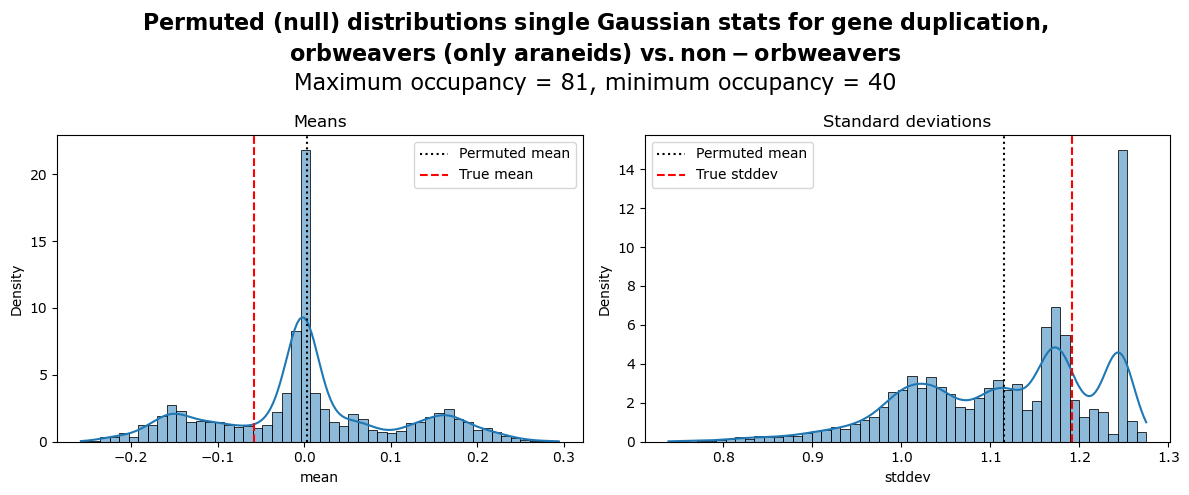

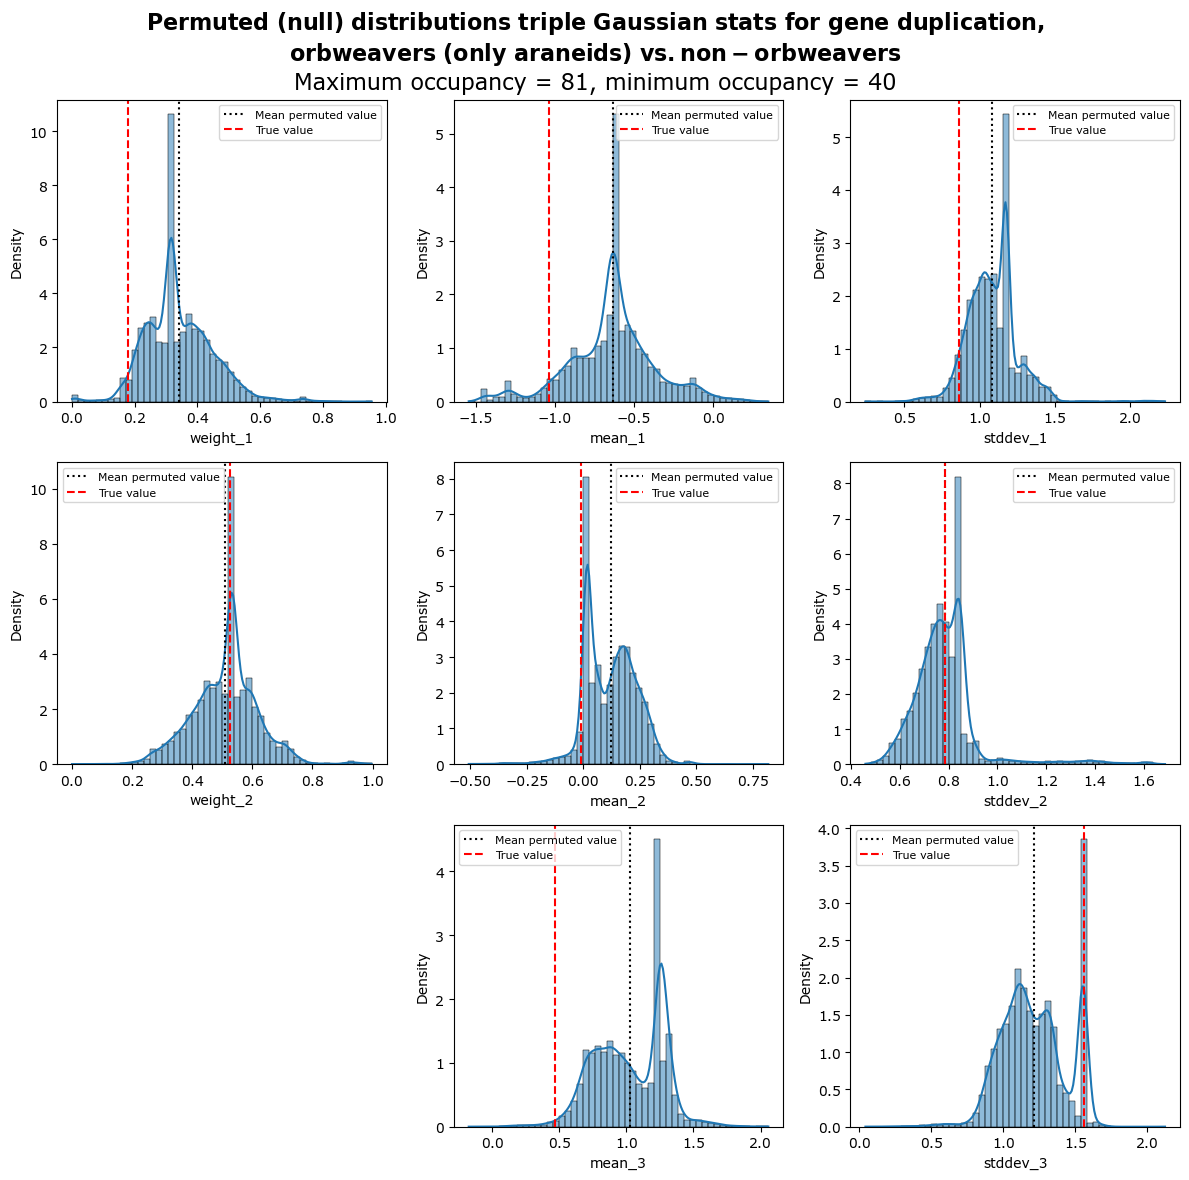

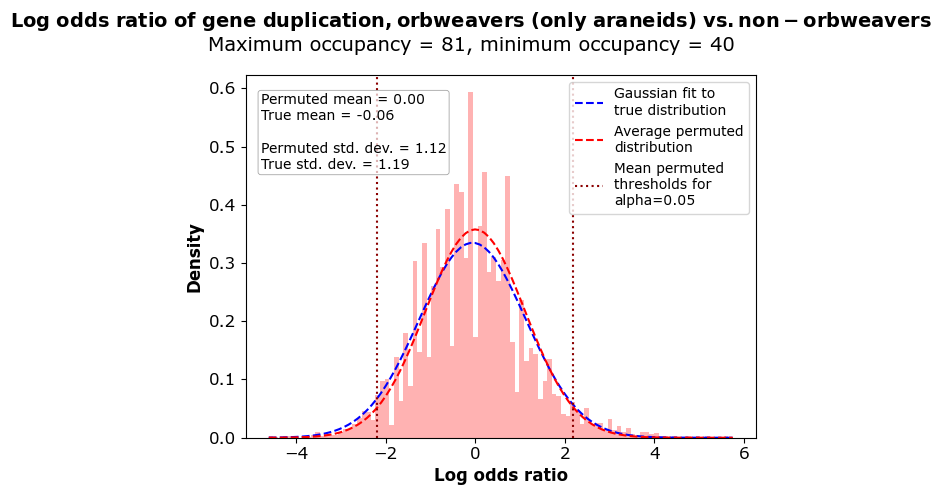

In [7]:
%autoreload 2
dup_rt_40_81 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=40,
    alternative="greater",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (only araneids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/araneids-orbweavers.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_only_araneids.csv",
    save_two_tailed_hits=True
)